In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

df = pd.read_excel("medicamentos_epilepsia_HU3.xlsx")
df.describe().T

,count,mean,min,25%,50%,75%,max,std
nregistro,988.0,58003971.409919,3275.0,79409.75,84385.5,90361.25,1231732001.0,247256346.393465
cn,988.0,717489.643725,600014.0,693678.0,721201.0,758160.25,918839.0,47933.676533
estado_aut,988,2016-06-09 22:37:59.773279,1922-10-01 00:00:00,2012-10-29 23:00:00,2018-02-05 23:00:00,2022-03-21 23:37:05.500000,2026-08-28 15:52:00,NaN
estado_rev,143,2024-07-30 06:53:11.825174,2021-11-02 15:39:52,2023-02-03 11:05:00,2024-10-11 11:31:04,2026-03-02 15:50:40.500000,2026-09-16 07:51:13,NaN
comercializado,988.0,0.625506,0.0,0.0,1.0,1.0,1.0,0.484237
requiere_receta,988.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
generico,988.0,0.860324,0.0,1.0,1.0,1.0,1.0,0.346826
afecta_conduccion,988.0,0.986842,0.0,1.0,1.0,1.0,1.0,0.114008
triangulo_negro,988.0,0.009109,0.0,0.0,0.0,0.0,1.0,0.095055
medicamento_huerfano,988.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.describe(include='object').T

,count,unique,top,freq
nombre,988,971,KEPPRA 100 mg/ml SOLUCION ORAL,3
pactivos,988,29,PREGABALINA,242
labtitular,988,103,Laboratorios Combix S.L.U.,56
labcomercializador,988,92,Teva Pharma S.L.U.,62
dosis,988,126,100 mg,101
forma_farmaceutica_simplificada,988,11,COMPRIMIDO,510
vias_administracion,988,4,VÍA ORAL,941
url_html_ficha_tecnica,988,988,https://cima.aemps.es/cima/dochtml/ft/62620/FT...,1
url_foto_materiales,192,192,https://cima.aemps.es/cima/fotos/thumbnails/ma...,1
Estado,584,4,ALTA,475


In [19]:
df_mod = df.drop(columns=['nregistro','cn','estado_rev', 'estado_aut', 'url_html_ficha_tecnica', 'url_foto_materiales'])
df_mod.head()

,nombre,pactivos,labtitular,labcomercializador,dosis,forma_farmaceutica_simplificada,vias_administracion,comercializado,requiere_receta,generico,...,num_principios_activos,num_excipientes,Volumen Informativo de Seguridad (num palabras),Complejidad del Desglose Clínico (num tablas),Indicador de Riesgo Severo (num veces grave/s),Estado,Precio venta al público con IVA,Precio de referencia,Tratamiento de larga duración,Especial control médico
0,CARBAMAZEPINA NORMON 200 mg COMPRIMIDOS EFG,CARBAMAZEPINA,Laboratorios Normon S.A.,Laboratorios Normon S.A.,200 mg carbamazepina,COMPRIMIDO,VÍA ORAL,1,1,1,...,1,0,2558,0,16,ALTA,3.98,3.98,SI,NO
1,CARBAMAZEPINA NORMON 400 mg COMPRIMIDOS EFG,CARBAMAZEPINA,Laboratorios Normon S.A.,Laboratorios Normon S.A.,400 mg carbamazepina,COMPRIMIDO,VÍA ORAL,1,1,1,...,1,0,2558,0,16,ALTA,7.96,7.96,SI,NO
2,CRISOMET 100 mg COMPRIMIDOS MASTICABLES/DISPER...,LAMOTRIGINA,Glaxosmithkline S.A.,Glaxosmithkline S.A.,100 mg lamotrigina,COMPRIMIDO MASTICABLE,VÍA ORAL,1,1,0,...,1,0,2420,8,16,BAJA POR NO COMERCIALIZAR,26.35,26.35,SI,NO
3,CRISOMET 200 mg COMPRIMIDOS MASTICABLES/DISPER...,LAMOTRIGINA,Glaxosmithkline S.A.,Glaxosmithkline S.A.,200 mg lamotrigina,COMPRIMIDO MASTICABLE,VÍA ORAL,1,1,0,...,1,0,2420,8,16,BAJA POR NO COMERCIALIZAR,28.24,28.24,SI,NO
4,CRISOMET 25 mg COMPRIMIDOS MASTICABLES/DISPERS...,LAMOTRIGINA,Glaxosmithkline S.A.,Glaxosmithkline S.A.,25 mg lamotrigina,COMPRIMIDO MASTICABLE,VÍA ORAL,1,1,0,...,1,0,2420,8,16,BAJA POR NO COMERCIALIZAR,6.59,6.59,SI,NO


<Axes: >

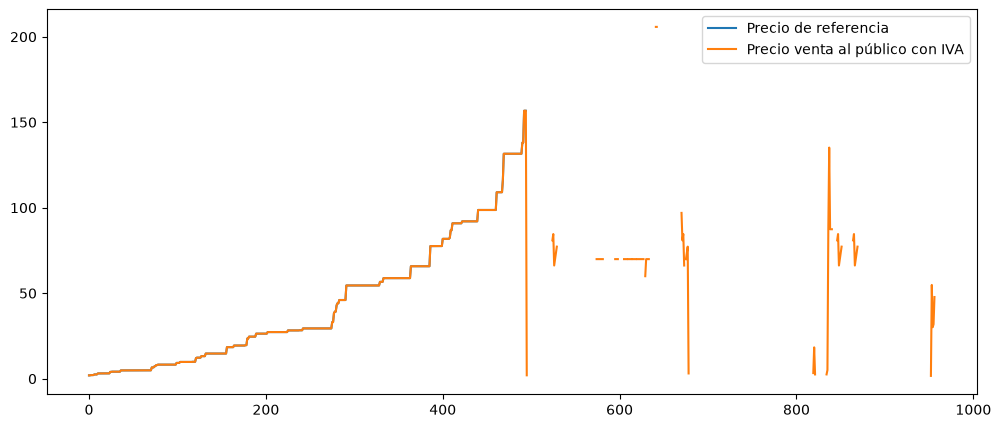

In [23]:
df_mod[["Precio de referencia", "Precio venta al público con IVA"]].sort_values("Precio de referencia").reset_index(drop=True).plot(figsize=(12, 5))


In [ ]:
#LOS DOS PRECIOS SON IGUALES MENOS EN POCOS CASOS QUE REFERENCIA NO TIENE VALOR, POR LO QUE ELIMINAMOS
#PRECIO REFERENCIA
df_mod = df_mod.drop(columns=['Precio de referencia'])


df_mod = df_mod.fillna({
    "Precio venta al público con IVA": -1,
})

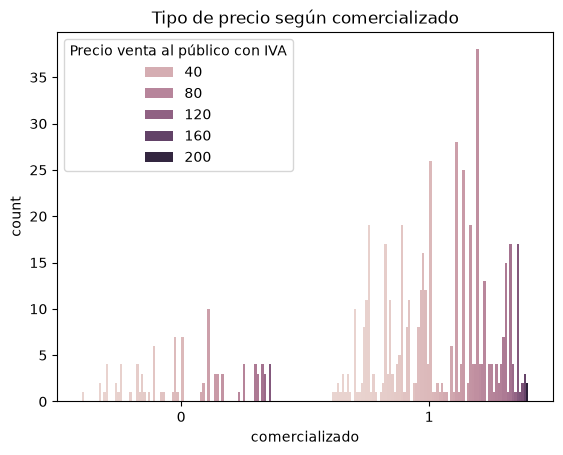

In [ ]:
sns.countplot(data=df_mod, x="comercializado", hue="Precio venta al público con IVA")
plt.title("Tipo de precio según comercializado")
plt.show() #no tiene ninguna relaciob, como vemos en la grafica hay precios con y sin comercializado, por lo que no tiene sentido eliminarlo, ya que no hay una relación entre comercializado y precio.